In [2]:
# Setup & Connect to Database

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [3]:
# Load Data from MySQL
# WHAT: Connect to MySQL and pull data
# WHY: We need to read our cleaned data from the view we created

# Import settings from config
import sys
sys.path.append(r'D:\Vaidehi Study\Regional_Sales_Analysis\04_scripts')
from config import DB_CONFIG

# Create connection
engine = create_engine(f"mysql+pymysql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}")

# Load data from our view
df = pd.read_sql("SELECT * FROM v_master_sales_report", con=engine)

print(f"✅ Data loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

✅ Data loaded successfully!
Total rows: 64,104
Total columns: 9


In [13]:
# First Look at Data
# WHY: Understand structure, column names, data types

print("=" * 80)
print("FIRST 5 ROWS OF DATA")
print("=" * 80)
print(df.head())

print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

print("\n" + "=" * 80)
print("DATA SHAPE")
print("=" * 80)
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

FIRST 5 ROWS OF DATA
    OrderNumber   OrderDate          Customer     Product        State  \
0   SO - 000225  2022-01-01     Rhynoodle Ltd  Product 27      Georgia   
1  SO - 0003378  2022-01-01    Thoughtmix Ltd  Product 20      Indiana   
2  SO - 0005126  2022-01-01   Amerisourc Corp  Product 26   California   
3  SO - 0005614  2022-01-01  Colgate-Pa Group   Product 7      Indiana   
4  SO - 0005781  2022-01-01     Deseret Group   Product 8  Connecticut   

          City  Qty  Price  Revenue  
0     Savannah    6    2.0     12.0  
1    Greenwood   11    2.0     22.0  
2   Pleasanton    6  978.2   5869.2  
3  Bloomington    7    2.0     14.0  
4   Manchester    8    2.0     16.0  

DATA TYPES
OrderNumber        str
OrderDate       object
Customer           str
Product            str
State              str
City               str
Qty              int64
Price          float64
Revenue        float64
dtype: object

DATA SHAPE
Rows: 64,104
Columns: 9


In [27]:
# Data Quality Checks
# WHAT: Check for problems in data (missing values, duplicates)
# WHY: Clean data = accurate analysis

print("=" * 80)
print("DATA QUALITY REPORT")
print("=" * 80)

# Check for missing values
print("\n1️⃣ MISSING VALUES:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found!")
else:
    print(missing[missing > 0])

# Check for duplicates
print("\n2️⃣ DUPLICATE ROWS:")
duplicates = df.duplicated().sum()
print(f"   Found: {duplicates}")

# Check date range
print("\n3️⃣ DATE RANGE:")
print(f"   From: {df['OrderDate'].min()}")
print(f"   To: {df['OrderDate'].max()}")

# Check revenue range
print("\n4️⃣ REVENUE STATISTICS:")
print(f"   Minimum: ${df['Revenue'].min():,.2f}")
print(f"   Maximum: ${df['Revenue'].max():,.2f}")
print(f"   Average: ${df['Revenue'].mean():,.2f}")
print(f"   Total: ${df['Revenue'].sum():,.2f}")

DATA QUALITY REPORT

1️⃣ MISSING VALUES:
   ✅ No missing values found!

2️⃣ DUPLICATE ROWS:
   Found: 0

3️⃣ DATE RANGE:
   From: 2022-01-01
   To: 2026-02-28

4️⃣ REVENUE STATISTICS:
   Minimum: $5.00
   Maximum: $11,979.60
   Average: $1,039.87
   Total: $66,659,528.40


In [28]:
# Business Metrics Summary
# WHAT: Calculate key business numbers
# WHY: These are KPIs (Key Performance Indicators) we'll put in dashboards

print("=" * 80)
print("KEY BUSINESS METRICS")
print("=" * 80)

total_revenue = df['Revenue'].sum()
total_orders = df['OrderNumber'].nunique()
total_customers = df['Customer'].nunique()
total_products = df['Product'].nunique()
avg_order_value = df['Revenue'].mean()

print(f"Total Revenue:       ${total_revenue:,.2f}")
print(f"Total Orders:        {total_orders:,}")
print(f"Total Customers:     {total_customers:,}")
print(f"Total Products:      {total_products:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

KEY BUSINESS METRICS
Total Revenue:       $66,659,528.40
Total Orders:        10,679
Total Customers:     175
Total Products:      30
Average Order Value: $1,039.87


TOP 10 PRODUCTS BY REVENUE
 1. Product 25           $   5,768,918.40
 2. Product 26           $   5,535,851.40
 3. Product 13           $   4,519,273.20
 4. Product 15           $   4,016,758.20
 5. Product 14           $   4,002,189.60
 6. Product 5            $   3,997,332.00
 7. Product 2            $   3,581,056.20
 8. Product 4            $   2,881,176.60
 9. Product 1            $   2,830,001.40
10. Product 17           $   2,741,323.80

✅ Chart saved to results folder


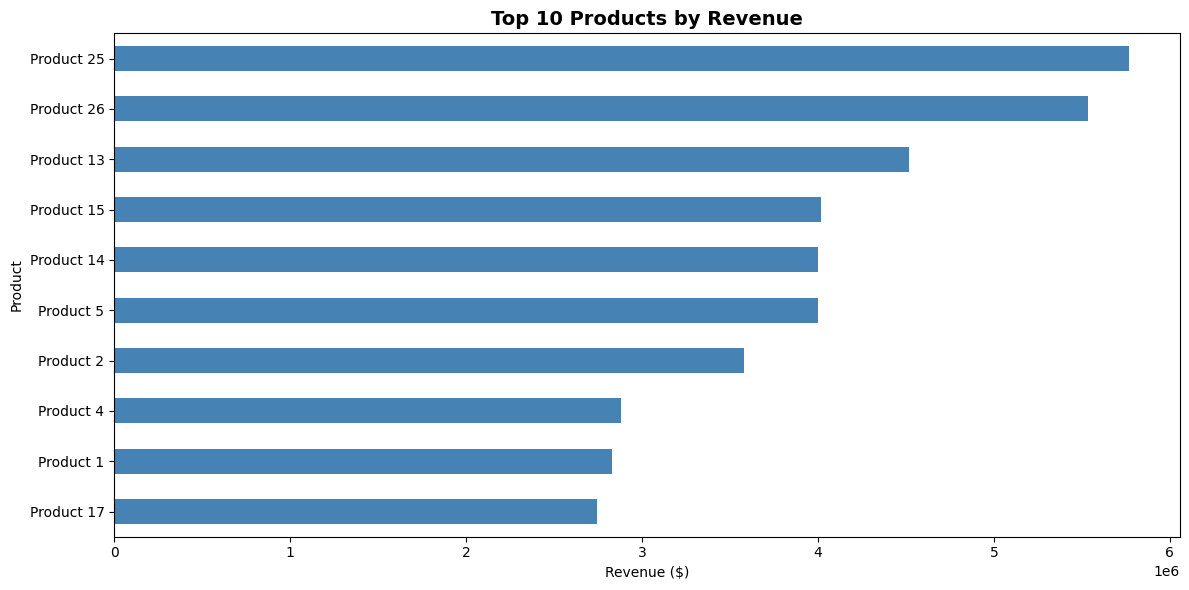

In [21]:
# WHAT: Find which products generate the most revenue, print and visualize the top 10 products and save the resulting chart as a PNG image.
# WHY: Business wants to know what's selling well

print("=" * 80)
print("TOP 10 PRODUCTS BY REVENUE")
print("=" * 80)

top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)
for i, (product, revenue) in enumerate(top_products.items(), 1):
    print(f"{i:2d}. {product:20s} ${revenue:>15,.2f}")

# Visualization
# Using .sort_values(ascending=True) here so the largest bar is at the TOP of the chart


plt.figure(figsize=(12, 6))
#top_products.plot(kind='barh', color='steelblue')
top_products.sort_values(ascending=True).plot(kind='barh', color='steelblue')
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('Product')
plt.tight_layout()

# Save the figure
plt.savefig(r'D:\Vaidehi Study\Regional_Sales_Analysis\05_results\01_top_products.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved to results folder")
plt.show()

Bottom 10 PRODUCTS BY REVENUE
 1. Product 9            $     704,030.40
 2. Product 24           $     778,633.20
 3. Product 28           $     831,242.40
 4. Product 7            $     833,421.60
 5. Product 23           $     927,243.60
 6. Product 30           $   1,027,906.20
 7. Product 12           $   1,034,140.80
 8. Product 8            $   1,050,949.20
 9. Product 11           $   1,069,552.20
10. Product 10           $   1,115,011.80

✅ Chart saved to results folder


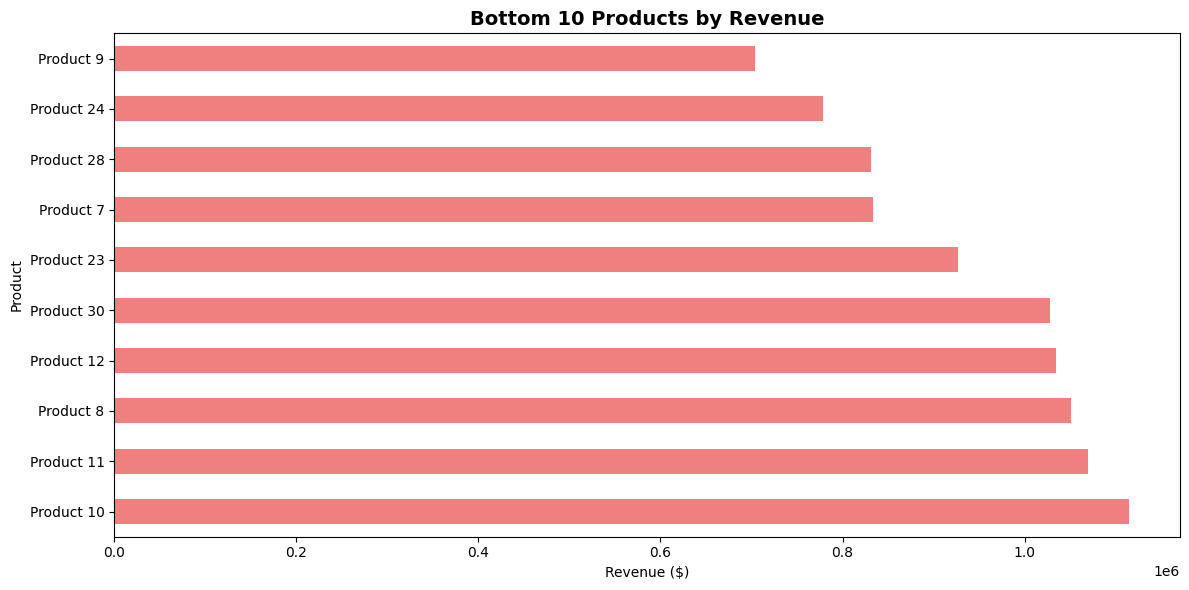

In [25]:
# Bottom 10 Products

print("=" * 80)
print("Bottom 10 PRODUCTS BY REVENUE")
print("=" * 80)

bottom_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=True).head(10)
for i, (product, revenue) in enumerate(bottom_products.items(), 1):
    print(f"{i:2d}. {product:20s} ${revenue:>15,.2f}")

# Visualization
plt.figure(figsize=(12, 6))

# Sort descending for the plot so the absolute lowest is at the top of the bar chart
bottom_products.sort_values(ascending=False).plot(kind='barh', color='lightcoral') 
plt.title('Bottom 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('Product')
plt.tight_layout()

# Save the figure
plt.savefig(r'D:\Vaidehi Study\Regional_Sales_Analysis\05_results\01_bottom_products.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved to results folder")
plt.show()  


In [26]:
# Calculating the Percentage Contribution

total_revenue = df['Revenue'].sum()
top_10_revenue = top_products.sum()
percentage = (top_10_revenue / total_revenue) * 100

print(f"Top 10 products contribute {percentage:.2f}% of total revenue.")


Top 10 products contribute 59.82% of total revenue.


REVENUE BY STATE (Ranked)
 1. California      $  12,517,562.90 ( 18.8%)
 2. Illinois        $   5,764,703.00 (  8.6%)
 3. Florida         $   4,802,339.90 (  7.2%)
 4. Texas           $   4,366,215.10 (  6.6%)
 5. Indiana         $   2,981,793.30 (  4.5%)
 6. New York        $   2,794,583.70 (  4.2%)
 7. Connecticut     $   2,438,383.40 (  3.7%)
 8. New Jersey      $   2,437,085.30 (  3.7%)
 9. Michigan        $   2,049,630.60 (  3.1%)
10. Massachusetts   $   1,793,923.10 (  2.7%)
11. Washington      $   1,661,940.10 (  2.5%)
12. Minnesota       $   1,552,415.90 (  2.3%)
13. Colorado        $   1,392,058.50 (  2.1%)
14. Arizona         $   1,305,838.50 (  2.0%)
15. Georgia         $   1,255,695.60 (  1.9%)
16. North Carolina  $   1,209,907.00 (  1.8%)
17. Ohio            $   1,204,543.50 (  1.8%)
18. Virginia        $   1,130,025.40 (  1.7%)
19. Pennsylvania    $   1,122,313.30 (  1.7%)
20. Maryland        $   1,115,247.90 (  1.7%)
21. Utah            $     988,845.90 (  1.5%)
22. Miss

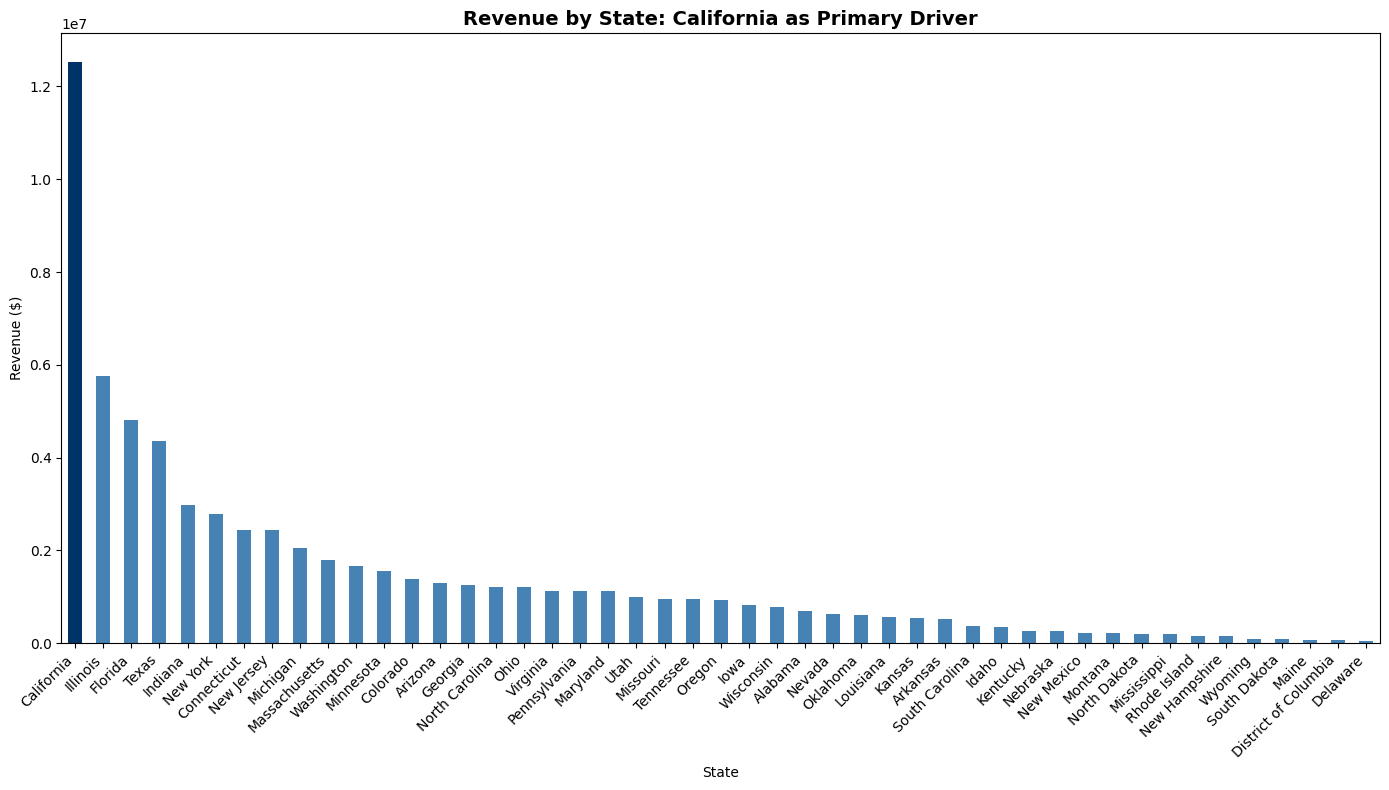

In [28]:
# WHAT: Top States (Regional Analysis) Which states generate the most revenue? 
# WHY: Your main business question: "Which region drives the most profit?"

print("=" * 80)
print("REVENUE BY STATE (Ranked)")
print("=" * 80)

state_revenue = df.groupby('State')['Revenue'].sum().sort_values(ascending=False)
for i, (state, revenue) in enumerate(state_revenue.items(), 1):
    pct = (revenue / state_revenue.sum()) * 100
    print(f"{i:2d}. {state:15s} ${revenue:>15,.2f} ({pct:5.1f}%)")

# Visualization
colors = ['#003366'] + ['steelblue'] * (len(state_revenue) - 1)
plt.figure(figsize=(14, 8))
state_revenue.plot(kind='bar', color=colors)
plt.title('Revenue by State: California as Primary Driver', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig(r'D:\Vaidehi Study\Regional_Sales_Analysis\05_results\02_revenue_by_state.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved to results folder")
plt.show()


MONTHLY REVENUE TREND
YearMonth
2022-01    1305145.6
2022-02    1256771.4
2022-03    1580290.4
2022-04    1197330.5
2022-05    1328354.5
2022-06    1377730.3
2022-07    1399233.5
2022-08    1213289.3
2022-09    1406160.3
2022-10    1281962.2
2022-11    1306543.5
2022-12    1264696.9
2023-01    1434506.6
2023-02    1161789.1
2023-03    1326835.5
2023-04    1298059.1
2023-05    1317456.4
2023-06    1371412.9
2023-07    1296723.5
2023-08    1413865.8
2023-09    1138983.5
2023-10    1404053.9
2023-11    1144419.8
2023-12    1380821.6
2024-01    1342392.5
2024-02    1268284.5
2024-03    1540521.2
2024-04    1329155.4
2024-05    1605950.2
2024-06    1304220.0
2024-07    1350163.8
2024-08    1408341.4
2024-09    1293785.0
2024-10    1335824.4
2024-11    1137384.4
2024-12    1356763.7
2025-01    1285604.1
2025-02    1321749.2
2025-03    1392125.3
2025-04    1175479.6
2025-05    1340795.1
2025-06    1286488.1
2025-07    1425142.8
2025-08    1243558.2
2025-09    1390965.2
2025-10    1531005.4
20

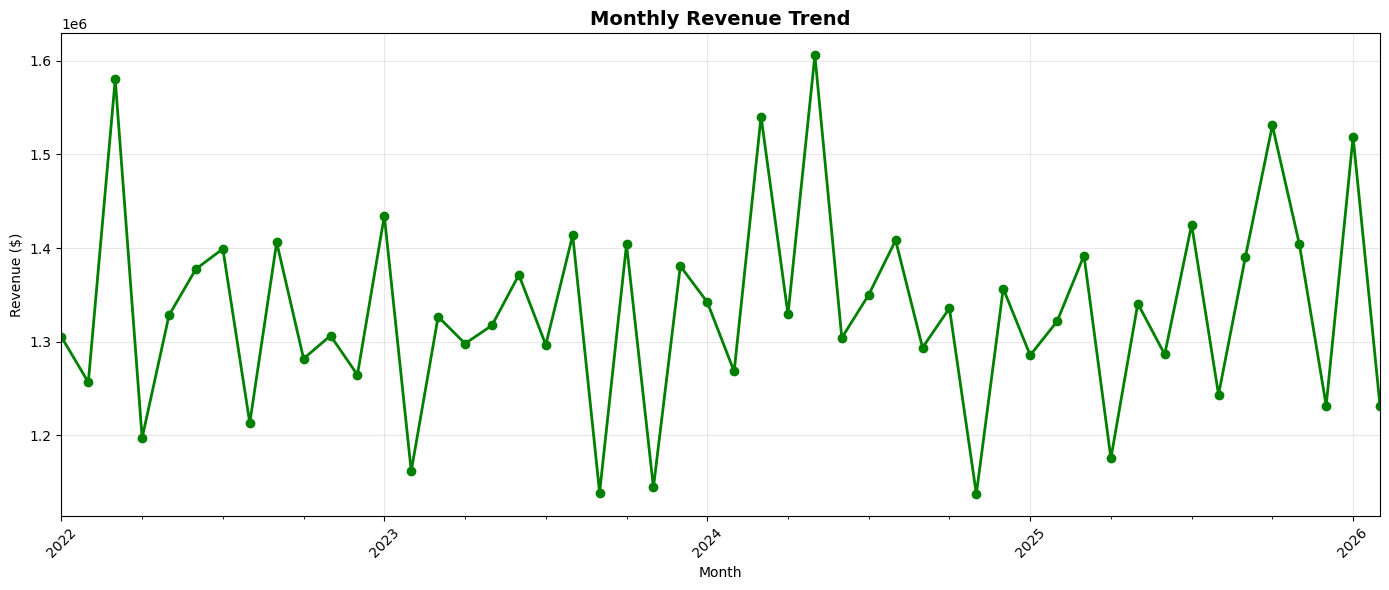

In [29]:
# WHAT:  Monthly Trend Analysis: How does revenue change month-by-month?
# WHY: Your second business question: "What is the monthly revenue trend?"

print("=" * 80)
print("MONTHLY REVENUE TREND")
print("=" * 80)

# Create year-month column
df['YearMonth'] = pd.to_datetime(df['OrderDate']).dt.to_period('M')

# Group by month
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()

print(monthly_revenue)

# Visualization
plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='line', marker='o', linewidth=2, markersize=6, color='green')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45) 
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(r'D:\Vaidehi Study\Regional_Sales_Analysis\05_results\03_monthly_trend.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved to results folder")
plt.show()


✅ Chart saved to results folder


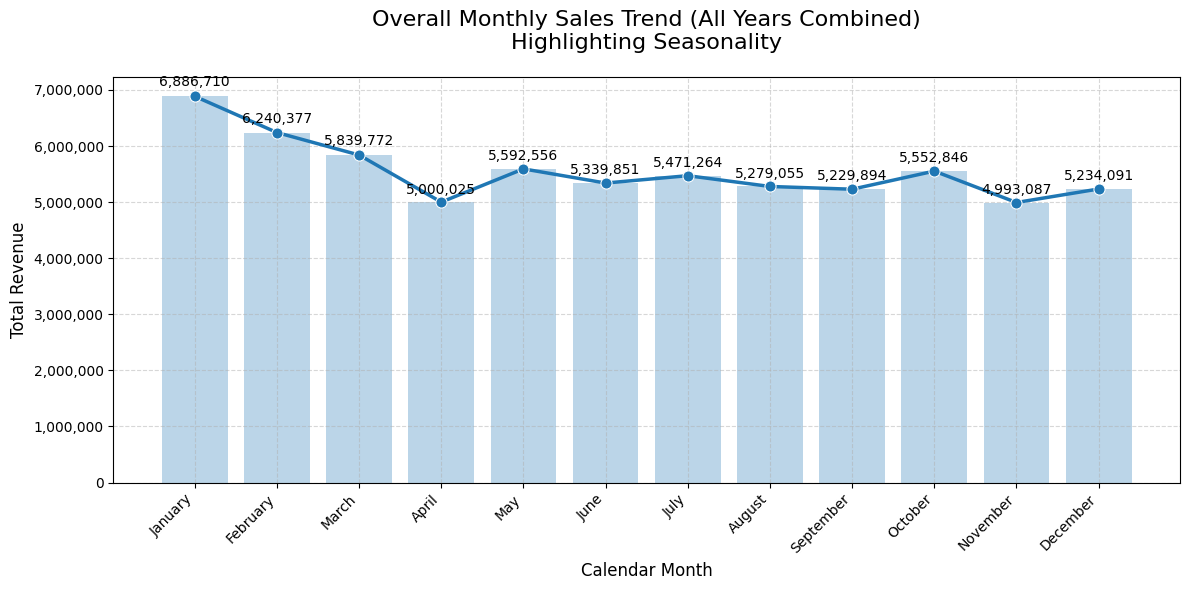

In [31]:

# I want to have a overall monthy sales trend for all years combined.
# The idea is to highlight the overall seasonality by aggregating the sales across all years for each calender month, 


# 1. Make sure OrderDate is datetime and extract calendar month
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['MonthNum'] = df['OrderDate'].dt.month
df['MonthName'] = df['OrderDate'].dt.strftime('%B')   # January, February, etc.

# 2. Aggregate total sales (Revenue) across ALL years for each calendar month
monthly_sales = (
    df.groupby(['MonthNum', 'MonthName'])['Revenue']
      .sum()
      .reset_index()
)

# 3. Sort by calendar month order (important for correct trend line)
monthly_sales = monthly_sales.sort_values('MonthNum')

# 4. Plot the overall monthly sales trend (seasonality)
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x='MonthName',
    y='Revenue',
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#1f77b4'
)

# adding a bar plot in background for better visual impact(optional)
plt.bar(
    monthly_sales['MonthName'],
    monthly_sales['Revenue'],
    alpha=0.3,
    color='#1f77b4'
)

plt.title('Overall Monthly Sales Trend (All Years Combined)\nHighlighting Seasonality', 
          fontsize=16, pad=20)
plt.xlabel('Calendar Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Format y-axis with commas for readability
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Rotate x labels for better readability
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each point
for i, row in monthly_sales.iterrows():
    plt.text(i, row['Revenue'] * 1.02, f'{row["Revenue"]:,.0f}', 
             ha='center', va='bottom', fontsize=10)
plt.savefig(r'D:\Vaidehi Study\Regional_Sales_Analysis\05_results\03_overall_monthly_trend_combined.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved to results folder")
plt.tight_layout()
plt.show()


✅ Chart saved to results folder


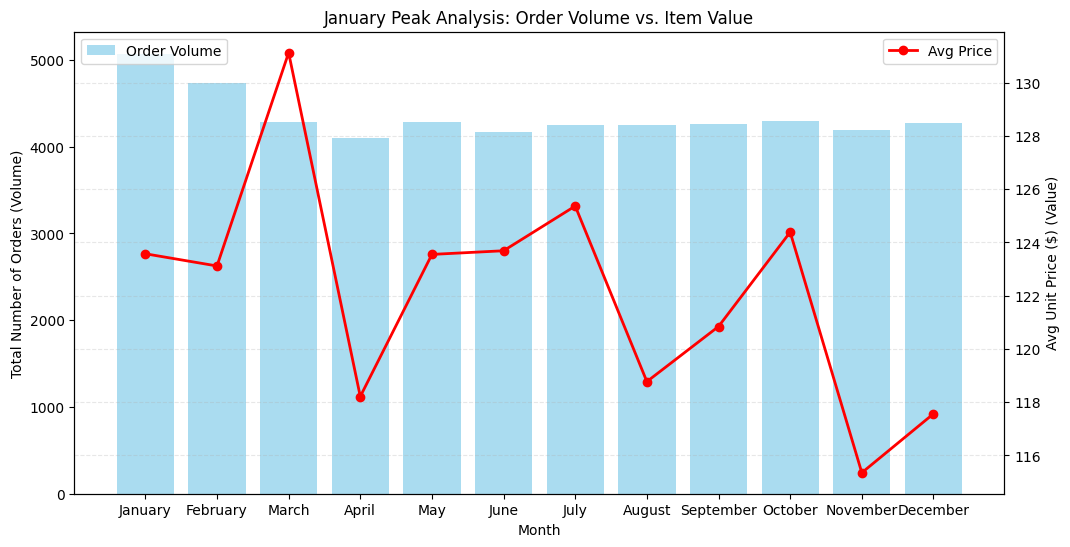

In [38]:
# Volume Vs Value
# Question: Is the January peak caused by more orders (high volume) or more expensive items (high unit price)?


# 1. Grouping by your 'MonthNum' and 'MonthName' columns
# This aggregates 2024 and 2025 together to see the "typical" monthly behavior
monthly_stats = df.groupby(['MonthNum', 'MonthName']).agg(
    total_revenue=('Revenue', 'sum'),
    order_count=('OrderNumber', 'nunique'), # Volume: Unique orders
    avg_unit_price=('Price', 'mean')         # Value: Average price per item
).reset_index().sort_values('MonthNum')

# 2. Visualization (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars for Volume (Order Count)
ax1.bar(monthly_stats['MonthName'], monthly_stats['order_count'], color='skyblue', alpha=0.7, label='Order Volume')
ax1.set_ylabel('Total Number of Orders (Volume)')
ax1.set_xlabel('Month')

# Line for Value (Average Price) on a second Y-axis
ax2 = ax1.twinx()
ax2.plot(monthly_stats['MonthName'], monthly_stats['avg_unit_price'], color='red', marker='o', linewidth=2, label='Avg Price')
ax2.set_ylabel('Avg Unit Price ($) (Value)')

plt.title('January Peak Analysis: Order Volume vs. Item Value')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig(r'D:\Vaidehi Study\Regional_Sales_Analysis\05_results\january_peak_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved to results folder")
plt.show()



In [35]:
df.head(2)

,OrderNumber,OrderDate,Customer,Product,State,City,Qty,Price,Revenue,YearMonth,MonthNum,MonthName,Month
0,SO - 000225,2022-01-01,Rhynoodle Ltd,Product 27,Georgia,Savannah,6,2.0,12.0,2022-01,1,January,1
1,SO - 0003378,2022-01-01,Thoughtmix Ltd,Product 20,Indiana,Greenwood,11,2.0,22.0,2022-01,1,January,1
